# SQF Optimisation — Interactive Notebook (v2026.1.0)
This notebook is currently being refactored to improve user-friendliness and allow easier reporting.

**Sections:**
- 1. Inputs / dataset
- 2. Model fitting
- 3. Prediction and Score Computation
- 4. Visualisation
- 5. Optimisation and Simulation
- 6. Simulation at arbitrary point

TODO: general cleanup and documentation

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from model import MethodConfig, fit_models, predict_grid_from_params, predict_single_point_from_params, predictions_to_xr, compute_scores, plot_score_surface

## Inputs / dataset

TODO: Add documentation


In [17]:
# config = MethodConfig(
#     T1 = 298.0,                # [K]
#     T2 = 313.0,                # [K]
#     tG1 = 8.0,                 # [min]
#     tG2 = 24.0,                # [min]
#     flow_mL_min = 0.5,         # [mL/min]
#     delay_volume_mL = 0.37,    # [mL]
#     t0_col_min = 0.64          # [min]
# )

with open("data/instrument-config_5_amlodipine.json", "r") as f:
    config_dict = json.load(f)
    config = MethodConfig(**config_dict)

In [18]:
# measurements = pd.DataFrame(
#     [
#         # analyte,  tR_T1_G1, tR_T1_G2, tR_T2_G1, tR_T2_G2,   w_T1_G1, w_T1_G2, w_T2_G1, w_T2_G2,   A_T1_G1, A_T1_G2, A_T2_G1, A_T2_G2,  area
#         ["CBDV",      4.00,     5.73,     3.77,     5.23,      0.06,    0.11,    0.06,    0.10,      1.40,    1.32,    1.58,    1.50,    7.0],
#         ["CBDA",      4.82,     7.75,     4.55,     7.11,      0.06,    0.12,    0.06,    0.12,      1.25,    1.23,    1.15,    1.11,    3.0],
#         ["CBGA",      5.02,     8.39,     4.71,     7.64,      0.06,    0.12,    0.06,    0.12,      1.06,    1.05,    1.02,    1.00,    5.0],
#         ["CBG",       5.13,     8.63,     4.86,     7.95,      0.06,    0.14,    0.06,    0.13,      1.11,    1.10,    1.08,    1.06,    10.0],
#         ["CBD",       5.21,     8.65,     4.93,     8.01,      0.06,    0.12,    0.06,    0.12,      1.28,    1.19,    1.22,    1.20,    13.0],
#         ["THCV",      5.28,     8.49,     4.93,     7.64,      0.07,    0.13,    0.06,    0.12,      0.95,    0.98,    0.97,    1.00,    8.0],
#         ["CBN",       6.17,     10.99,    5.76,     9.96,      0.07,    0.14,    0.06,    0.14,      1.89,    1.92,    1.74,    1.78,    9.0],
#         ["delta9THC", 6.70,     12.32,    6.26,     11.19,     0.07,    0.15,    0.07,    0.15,      1.32,    1.30,    1.22,    1.19,    10.0],
#         ["delta8THC", 6.80,     12.60,    6.36,     11.47,     0.07,    0.15,    0.07,    0.15,      1.21,    1.20,    1.19,    1.17,    13.0],
#         ["CBC",       7.24,     13.97,    6.77,     12.72,     0.07,    0.15,    0.07,    0.15,      1.15,    1.12,    1.12,    1.10,    7.0],
#         ["THCA",      7.35,     14.11,    6.83,     12.72,     0.07,    0.16,    0.07,    0.15,      1.08,    1.06,    1.05,    1.03,    10.0],
#         # ...
#     ],
#     columns=[
#         "analyte",
#         "tR_T1_G1","tR_T1_G2","tR_T2_G1","tR_T2_G2",
#         "w_T1_G1","w_T1_G2","w_T2_G1","w_T2_G2",
#         "A_T1_G1","A_T1_G2","A_T2_G1","A_T2_G2",
#         "area",
#     ],
# )

measurements = pd.read_csv("data/measurements_5_amlodipine.csv", index_col=False, skipinitialspace=True)
measurements = measurements.set_index("analyte")



## Model fitting

TODO: Description of the model


In [19]:
model_params = fit_models(config, measurements)
display(model_params)

,a1,a2,a0,b1,b2,b0,c1,c2,c0
analyte,,,,,,,,,
Amlodipine,726.519921,-4.040466,-1.620529,254.955594,-1.944978,-3.684371,-111.680099,0.040359,0.481036
Imp A,423.673467,-3.697977,0.538091,294.898877,-2.513125,-3.452187,-0.000000,0.201828,0.063752
Imp B,199.188892,-3.273911,0.532810,144.955055,-2.003242,-3.265879,-0.000000,0.040359,0.099876
Imp D,893.159524,-2.883603,-2.780272,258.297509,-1.845870,-3.719289,-84.883148,0.040724,0.380489
Imp E,555.058192,-4.100172,-0.776134,256.455104,-1.989749,-3.650923,-56.334235,-0.081820,0.305718
Imp F,963.572357,-0.632619,-3.124862,237.613313,-1.853074,-3.651043,-28.292865,-0.000000,0.200923
Imp G,561.805782,-3.071697,-0.679222,297.426498,-1.593484,-3.679350,-28.809637,-0.211306,0.207983
Imp H,347.907295,-3.376779,0.152501,239.241324,-1.194565,-3.613738,107.861219,-0.606297,-0.126807


## Prediction and Score Computation

TODO: Include documentation before code  
TODO: Clean up output


In [20]:
# --- build predictions on the full grid ---
T_vals = np.linspace(*config.T_levels, 1000)
tG_vals = np.linspace(*config.tG_levels, 1000)

grid_tR, grid_w, grid_S = predict_grid_from_params(
    model_params,
    T_vals=T_vals,
    tG_vals=tG_vals,
    t0_total=float(config.t0_total_min),
)

pred_grid = predictions_to_xr(
    grid_tR,
    grid_w,
    grid_S,
    T_vals=T_vals,
    tG_vals=tG_vals,
    analytes=list(model_params.index),
)

# --- compute scores ---
scores_grid = compute_scores(
    pred_grid,
    column_dead_time=float(config.t0_col_min),
    width_penalty_coeff=10.0,
)

display(pred_grid)
display(scores_grid)

c:\Users\Mathias\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


<xarray.Dataset> Size: 192MB
Dimensions:  (analyte: 8, T: 1000, tG: 1000)
Coordinates:
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
  * T        (T) float64 8kB 293.0 293.0 293.1 293.1 ... 322.9 322.9 323.0 323.0
  * tG       (tG) float64 8kB 3.0 3.006 3.012 3.018 ... 8.982 8.988 8.994 9.0
Data variables:
    tR       (analyte, T, tG) float64 64MB 1.164 1.166 1.167 ... 2.899 2.899 2.9
    w        (analyte, T, tG) float64 64MB 0.03135 0.03139 ... 0.0495 0.0495
    A        (analyte, T, tG) float64 64MB 1.12 1.12 1.12 ... 1.15 1.15 1.15

<xarray.Dataset> Size: 56MB
Dimensions:  (tG: 1000, T: 1000, analyte: 8)
Coordinates:
  * tG       (tG) float64 8kB 3.0 3.006 3.012 3.018 ... 8.982 8.988 8.994 9.0
  * T        (T) float64 8kB 293.0 293.0 293.1 293.1 ... 322.9 322.9 323.0 323.0
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
Data variables:
    eta      (T, tG) float64 8MB 0.8785 0.8786 0.8787 ... 0.9455 0.9455 0.9455
    Sbar     (T, tG) float64 8MB 0.9132 0.9131 0.9131 ... 0.8912 0.8912 0.8912
    We       (T, tG) float64 8MB 0.6 0.6002 0.6005 ... 0.4027 0.4026 0.4024
    DUr      (T, tG) float64 8MB 0.5216 0.5216 0.5215 ... 0.5321 0.5321 0.5321
    CPO      (T, tG) float64 8MB 0.0 0.001539 0.003075 ... 0.5305 0.5298 0.5291
    SQF      (T, tG) float64 8MB 0.0 0.2077 0.2386 ... 0.6256 0.6253 0.6251
    Rs_crit  (T, tG) float64 8MB 0.0 0.003078 0.00615 ... 1.07 1.069 1.068

## Visualisation

TODO: Plot metric surfaces and SQF; export publication-ready figures.


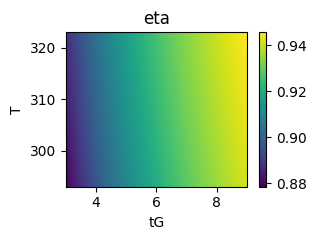

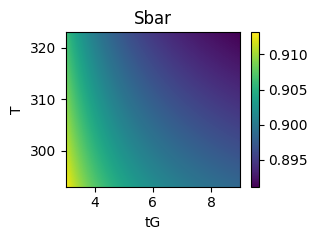

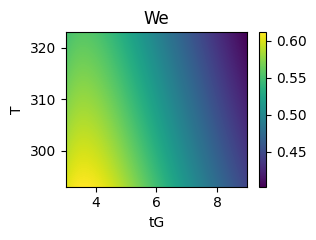

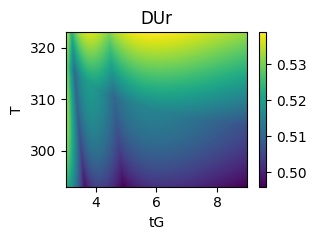

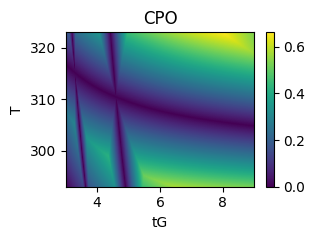

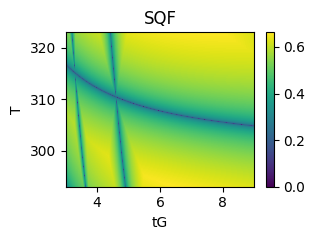

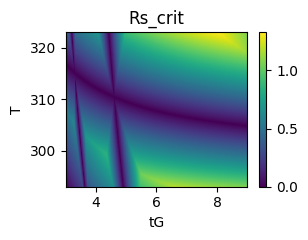

In [21]:
# Plot all available score surfaces (one figure per score)
for score_name in list(scores_grid.data_vars):
    plot_score_surface(scores_grid, str(score_name))

## Optimisation and Simulation

TODO: Locate optimum and simulate its chromatogram


In [22]:
# ---- Select optimum point ----
sqf = scores_grid["SQF"].transpose("T", "tG")

# index of the global minimum in the 2D array
i_T, i_tG = np.unravel_index(np.nanargmax(sqf.values), sqf.shape)

# corresponding coordinate values
T_max = float(sqf.coords["T"].values[i_T])
tG_max = float(sqf.coords["tG"].values[i_tG])
sqf_max = float(sqf.values[i_T, i_tG])

print(f"Optimum found at T={T_max:.2f} K, tG={tG_max:.2f} min with SQF={sqf_max:.4f}")

# ---- Predict ----
opt_tR, opt_w, opt_A = predict_single_point_from_params(
    model_params,
    T=T_max,
    tG=tG_max,
    t0_total=float(config.t0_total_min),
)

# Wrap scalars into (1,1) arrays per analyte so we get (N,1,1)
opt_tR_111 = {k: np.array([[v]], dtype=float) for k, v in opt_tR.items()}
opt_w_111  = {k: np.array([[v]], dtype=float) for k, v in opt_w.items()}
opt_A_111  = {k: np.array([[v]], dtype=float) for k, v in opt_A.items()}

pred_opt = predictions_to_xr(
    opt_tR_111,
    opt_w_111,
    opt_A_111,
    T_vals=np.array([T_max], dtype=float),
    tG_vals=np.array([tG_max], dtype=float),
    analytes=list(model_params.index),
)

# ---- Compute scores ----
scores_opt = compute_scores(
    pred_opt,
    column_dead_time=float(config.t0_col_min),
    width_penalty_coeff=10.0,  # keep consistent with your notebook
)

# ---- Display results ----
display(pred_opt)
display(scores_opt)

Optimum found at T=323.00 K, tG=8.01 min with SQF=0.6626


<xarray.Dataset> Size: 528B
Dimensions:  (analyte: 8, T: 1, tG: 1)
Coordinates:
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
  * T        (T) float64 8B 323.0
  * tG       (tG) float64 8B 8.009
Data variables:
    tR       (analyte, T, tG) float64 64B 1.682 4.557 2.647 ... 2.517 2.793
    w        (analyte, T, tG) float64 64B 0.04337 0.05767 ... 0.05195 0.04869
    A        (analyte, T, tG) float64 64B 1.151 1.093 1.111 ... 1.12 1.097 1.14

<xarray.Dataset> Size: 392B
Dimensions:  (tG: 1, T: 1, analyte: 8)
Coordinates:
  * tG       (tG) float64 8B 8.009
  * T        (T) float64 8B 323.0
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
Data variables:
    eta      (T, tG) float64 8B 0.9402
    Sbar     (T, tG) float64 8B 0.892
    We       (T, tG) float64 8B 0.4306
    DUr      (T, tG) float64 8B 0.5347
    CPO      (T, tG) float64 8B 0.6614
    SQF      (T, tG) float64 8B 0.6626
    Rs_crit  (T, tG) float64 8B 1.323

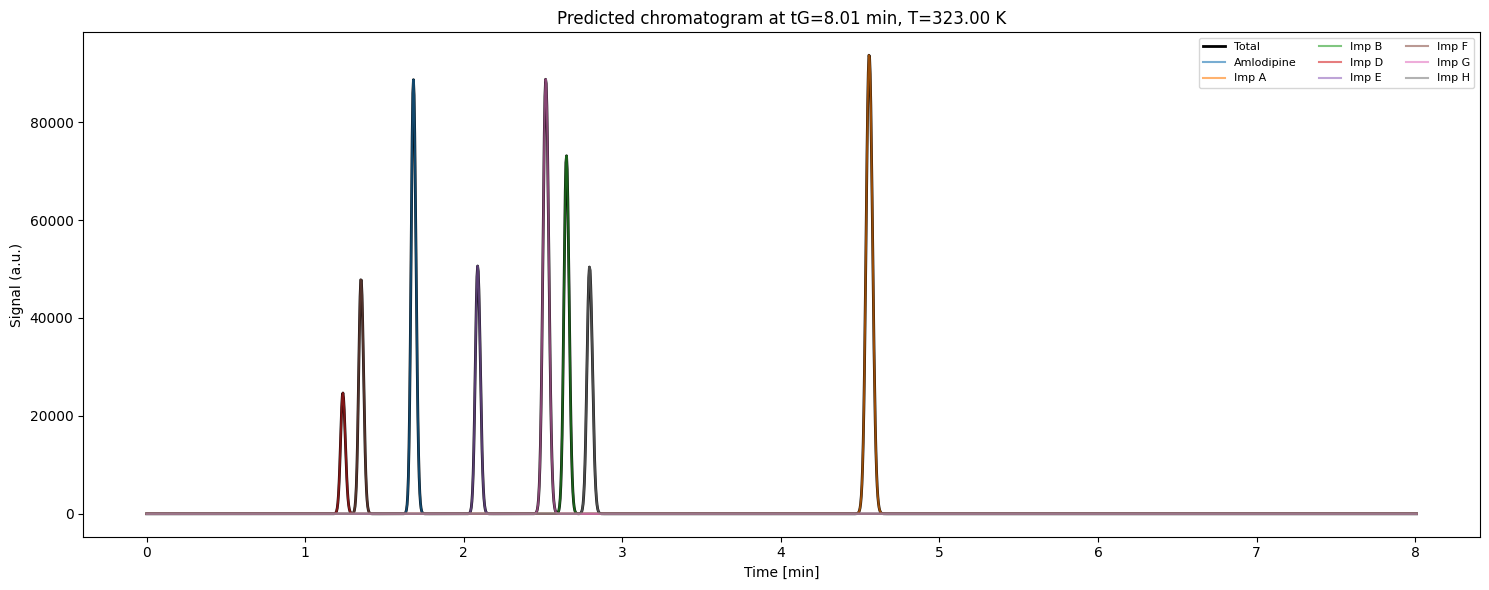

In [23]:
# --- Optimum-point synthetic chromatogram (transcribed to the xarray single-point test) ---

# Assumes you already ran the optimum point cell above and have:
# - pred_opt : xr.Dataset with vars tR, w, S and dims (analyte, T, tG)
# - T_min, tG_min : the selected optimum conditions

# Extract per-analyte scalars at the single point (T=0, tG=0)
tR_opt = pred_opt["tR"].isel(T=0, tG=0).values  # (N,)
w_opt  = pred_opt["w"].isel(T=0, tG=0).values   # (N,)
A_opt  = pred_opt["A"].isel(T=0, tG=0).values   # (N,)
analytes = pred_opt.coords["analyte"].values.tolist()

a_opt = np.array(measurements["area"], dtype=float)  # (N,)

# Convert (w, S) into asymmetric left/right widths (same as old notebook)
w_left  = 2.0 * w_opt / (A_opt + 1.0)
w_right = 2.0 * w_opt * A_opt / (A_opt + 1.0)

# Time axis for simulated chromatogram
x = np.linspace(0.0, float(tG_max), 2000)  # increase points for smoothness

# Broadcasted peak model:
# y_i(x) = a_i * exp( -4 * (tR_i - x)^2 / w_i(x)^2 )
# where w_i(x) = w_left_i if x < tR_i else w_right_i
rt = tR_opt[:, None]            # (N,1)
xx = x[None, :]                # (1,X)
wl = w_left[:, None]           # (N,1)
wr = w_right[:, None]          # (N,1)
aa = a_opt[:, None]             # (N,1)

w_piece = np.where(xx < rt, wl, wr)  # (N,X)
y = aa * np.exp(-4.0 * ((rt - xx) ** 2) / (w_piece ** 2))  # (N,X)
y_total = np.sum(y, axis=0)  # (X,)


# Overlay individual peaks (comment out if too cluttered)
plt.figure(figsize=(15, 6))
plt.plot(x, y_total, linewidth=2.0, label="Total", color="black")
for i, k in enumerate(analytes):
    plt.plot(x, y[i], label=k, alpha=0.6)
plt.title(f"Predicted chromatogram at tG={tG_max:.2f} min, T={T_max:.2f} K")
plt.xlabel("Time [min]")
plt.ylabel("Signal (a.u.)")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# Simple total chromatogram plot (replace the above if too cluttered)
# plt.figure(figsize=(15, 6))
# plt.plot(x, y_total)
# plt.title(f"Predicted chromatogram at tG={tG_test:.2f} min, T={T_test:.2f} K")
# plt.xlabel("Time [min]")
# plt.ylabel("Signal (a.u.)")
# plt.tight_layout()
# plt.show()


## Simulation at arbitrary point

TODO: Evaluate arbitrary (T, tG), print breakdown, and generate a synthetic chromatogram.


In [24]:
# ---- Choose a test point (edit as desired) ----
T_test = float(config.T1)   # or any temperature in your domain
tG_test = float(config.tG1) # or any gradient time in your domain

# ---- Predict ----
sp_tR, sp_w, sp_A = predict_single_point_from_params(
    model_params,
    T=T_test,
    tG=tG_test,
    t0_total=float(config.t0_total_min),
)

# Wrap scalars into (1,1) arrays per analyte so we get (N,1,1)
sp_tR_111 = {k: np.array([[v]], dtype=float) for k, v in sp_tR.items()}
sp_w_111  = {k: np.array([[v]], dtype=float) for k, v in sp_w.items()}
sp_A_111  = {k: np.array([[v]], dtype=float) for k, v in sp_A.items()}

pred_sp = predictions_to_xr(
    sp_tR_111,
    sp_w_111,
    sp_A_111,
    T_vals=np.array([T_test], dtype=float),
    tG_vals=np.array([tG_test], dtype=float),
    analytes=list(model_params.index),
)

# ---- Compute scores ----
scores_sp = compute_scores(
    pred_sp,
    column_dead_time=float(config.t0_col_min),
    width_penalty_coeff=10.0,  # keep consistent with your notebook
)

# ---- Display results ----
display(pred_sp)
display(scores_sp)

c:\Users\Mathias\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


<xarray.Dataset> Size: 528B
Dimensions:  (analyte: 8, T: 1, tG: 1)
Coordinates:
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
  * T        (T) float64 8B 293.0
  * tG       (tG) float64 8B 3.0
Data variables:
    tR       (analyte, T, tG) float64 64B 1.164 2.67 1.679 ... 1.504 1.789 1.789
    w        (analyte, T, tG) float64 64B 0.03135 0.0375 ... 0.04095 0.04095
    A        (analyte, T, tG) float64 64B 1.12 1.14 1.12 1.11 ... 1.11 1.04 1.04

<xarray.Dataset> Size: 392B
Dimensions:  (tG: 1, T: 1, analyte: 8)
Coordinates:
  * tG       (tG) float64 8B 3.0
  * T        (T) float64 8B 293.0
  * analyte  (analyte) <U10 320B 'Amlodipine' 'Imp A' ... 'Imp G' 'Imp H'
Data variables:
    eta      (T, tG) float64 8B 0.8785
    Sbar     (T, tG) float64 8B 0.9132
    We       (T, tG) float64 8B 0.6
    DUr      (T, tG) float64 8B 0.5216
    CPO      (T, tG) float64 8B 0.0
    SQF      (T, tG) float64 8B 0.0
    Rs_crit  (T, tG) float64 8B 0.0

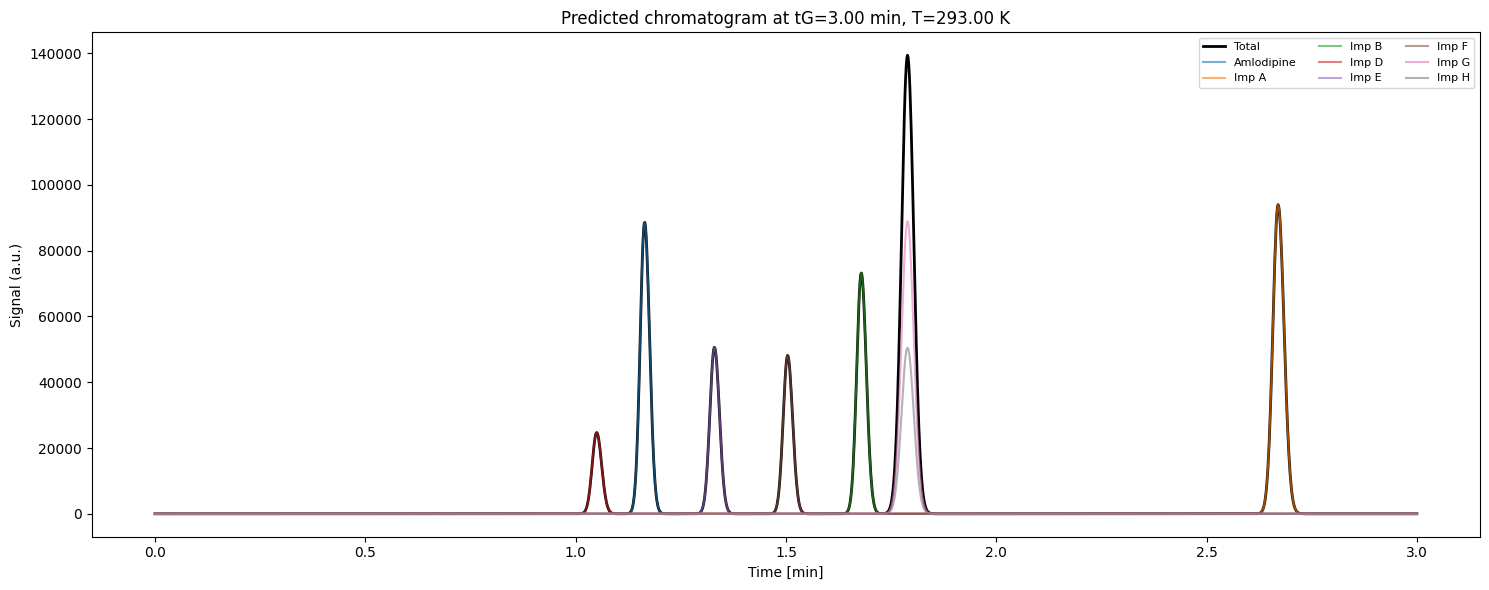

In [25]:
# --- Single-point synthetic chromatogram (transcribed to the xarray single-point test) ---

# Assumes you already ran the single-point test cell and have:
# - pred_sp : xr.Dataset with vars tR, w, S and dims (analyte, T, tG)
# - T_test, tG_test : the selected single-point conditions

# Extract per-analyte scalars at the single point (T=0, tG=0)
tR_sp = pred_sp["tR"].isel(T=0, tG=0).values  # (N,)
w_sp  = pred_sp["w"].isel(T=0, tG=0).values   # (N,)
A_sp  = pred_sp["A"].isel(T=0, tG=0).values   # (N,)
analytes = pred_sp.coords["analyte"].values.tolist()

a_sp = np.array(measurements["area"], dtype=float)  # (N,)

# Convert (w, S) into asymmetric left/right widths (same as old notebook)
w_left  = 2.0 * w_sp / (A_sp + 1.0)
w_right = 2.0 * w_sp * A_sp / (A_sp + 1.0)

# Time axis for simulated chromatogram
x = np.linspace(0.0, float(tG_test), 2000)  # increase points for smoothness

# Broadcasted peak model:
# y_i(x) = a_i * exp( -4 * (tR_i - x)^2 / w_i(x)^2 )
# where w_i(x) = w_left_i if x < tR_i else w_right_i
rt = tR_sp[:, None]            # (N,1)
xx = x[None, :]                # (1,X)
wl = w_left[:, None]           # (N,1)
wr = w_right[:, None]          # (N,1)
aa = a_sp[:, None]             # (N,1)

w_piece = np.where(xx < rt, wl, wr)  # (N,X)
y = aa * np.exp(-4.0 * ((rt - xx) ** 2) / (w_piece ** 2))  # (N,X)
y_total = np.sum(y, axis=0)  # (X,)


# Overlay individual peaks (comment out if too cluttered)
plt.figure(figsize=(15, 6))
plt.plot(x, y_total, linewidth=2.0, label="Total", color="black")
for i, k in enumerate(analytes):
    plt.plot(x, y[i], label=k, alpha=0.6)
plt.title(f"Predicted chromatogram at tG={tG_test:.2f} min, T={T_test:.2f} K")
plt.xlabel("Time [min]")
plt.ylabel("Signal (a.u.)")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# Simple total chromatogram plot (replace the above if too cluttered)
# plt.figure(figsize=(15, 6))
# plt.plot(x, y_total)
# plt.title(f"Predicted chromatogram at tG={tG_test:.2f} min, T={T_test:.2f} K")
# plt.xlabel("Time [min]")
# plt.ylabel("Signal (a.u.)")
# plt.tight_layout()
# plt.show()


## End of Document

Anything below this line is currently being refactored

---
